# **Prostate Cancer (PI-CAI)**

Dataset: Unveiling Prostate Cancer: MRI Insights for Detection and Diagnosis

In [ ]:
# =============================================================================
#  PROSTATE CANCER (PI-CAI) — CNN vs TRANSFORMER vs HYBRID BENCHMARK
#  Dataset : https://www.kaggle.com/datasets/varshithpsingh/prostate-cancer-pi-cai-dataset
#  Models  : ResNet-50 | EfficientNet-B3 | ViT-B/16 | Swin-T | Hybrid CNN-Transformer
#  Author  : Md. Abu Sayem
#  Runtime : Google Colab (GPU: T4 / L4 / A100)  -->  Runtime > Change runtime type > GPU

In [ ]:
# STEP 0 — INSTALL DEPENDENCIES
# timm       -> pretrained ResNet / EfficientNet / ViT / Swin
# kagglehub  -> Kaggle theke dataset download
# statsmodels-> McNemar test (best 2 model er difference statistically significant kina)
import subprocess, sys

def pip_install(pkgs):
    """Colab e quiet install. Local e o kaj korbe."""
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

pip_install([
    "timm>=1.0.7",          # model zoo
    "kagglehub",            # dataset download
    "scikit-learn>=1.3",    # metrics
    "seaborn",              # plots
    "statsmodels",          # McNemar test
    "pandas", "matplotlib", "tqdm",
])
print(" Dependencies installed.")


 Dependencies installed.


In [ ]:
# STEP 1 — IMPORTS + GLOBAL CONFIG + REPRODUCIBILITY

import os, re, json, time, random, warnings, glob
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, cohen_kappa_score, matthews_corrcoef)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

# ----------------------------- CONFIG ---------------------------------------
CFG = {
    # --- raw data (.mha volumes) ---
    "RAW_ROOT":       "/kaggle/input/prostate-cancer-pi-cai-dataset",
    "PNG_DIR":        "/kaggle/working/picai_png",   # Colab hole: /content/picai_png
    "TASK":           "csPCa",    # "csPCa" = binary (recommended) | "ISUP" = 6-class
    "SEQUENCES":      ("t2w", "adc", "hbv"),  # bpMRI 3 channel (sag/cor baad)
    "CROP_MM":        100,        # prostate er around koto mm center crop
    "SLICE_FRAC":     0.45,       # central koto % axial slice nibo (prostate zone)
    "LIMIT_CASES":    None,       # test run er jonno 100 dao, full run e None
    "N_JOBS":         4,          # preprocessing parallel workers

    # --- data ---
    "DATA_ROOT":      None,       # STEP 2 e PNG_DIR set hobe (None rakho)
    "IMG_SIZE":       224,        # sob model er common input size (fair comparison)
    "VAL_SIZE":       0.15,       # train theke 15% validation
    "TEST_SIZE":      0.15,       # 15% held-out test
    "GROUP_SPLIT":    True,       # True = patient-wise split (DATA LEAKAGE ATKAY!)
    "PATIENT_REGEX":  r"(\d{5,})",# filename theke patient id ber korar pattern

    # --- training ---
    "EPOCHS":         20,
    "BATCH_SIZE":     32,         # OOM hole 16 ba 8 koro (specially ViT/Swin)
    "NUM_WORKERS":    2,
    "WEIGHT_DECAY":   1e-4,
    "LABEL_SMOOTH":   0.05,
    "EARLY_STOP":     6,          # koto epoch improvement na hole thambe
    "USE_AMP":        True,       # mixed precision -> 2x faster, kom memory
    "BALANCE":        True,       # class imbalance handle (PI-CAI e beshi imbalanced)

    # --- misc ---
    "SEED":           42,
    "OUT_DIR":        "/kaggle/working/picai_results",  # Colab hole "./picai_results"
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(CFG["OUT_DIR"], exist_ok=True)

def seed_everything(seed=42):
    """Result reproducible korar jonno — paper e ei seed mention korte hobe."""
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(CFG["SEED"])
print(f" Device: {DEVICE}  |  torch {torch.__version__}  |  timm {timm.__version__}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


 Device: cuda  |  torch 2.11.0+cu128  |  timm 1.0.28
   GPU: Tesla T4


 Label distribution (case-level):
label_name
benign    1031
csPCa      408
Name: count, dtype: int64 

 Studies on disk        : 1500
 Studies with label+image: 1439

 1439 case process hocche (4 worker)...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   12.0s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done 280 tasks      | elapsed:  5.2min
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  8.1min
[Parallel(n_jobs=4)]: Done 640 tasks      | elapsed: 12.0min
[Parallel(n_jobs=4)]: Done 874 tasks      | elapsed: 15.9min
[Parallel(n_jobs=4)]: Done 1144 tasks      | elapsed: 21.0min
[Parallel(n_jobs=4)]: Done 1439 out of 1439 | elapsed: 26.2min finished



 14905 slice save holo | 0 case fail | 26.2 min
   benign     : 10711 slices
   csPCa      : 4194 slices


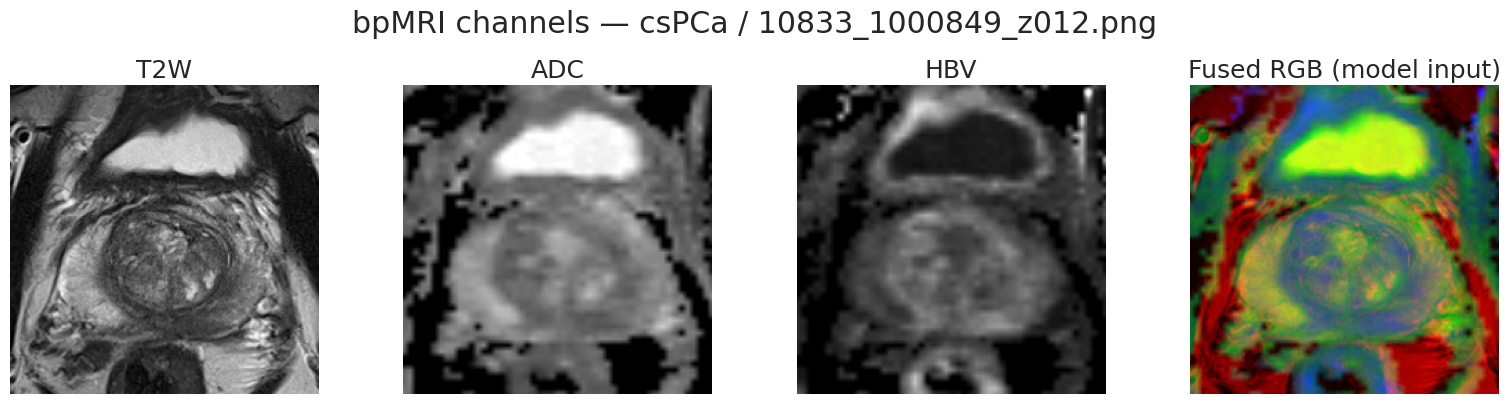

In [ ]:
# STEP 2 — RAW .mha VOLUME  ->  2D bpMRI PNG SLICES

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "SimpleITK", "joblib"], check=False)
import SimpleITK as sitk
from joblib import Parallel, delayed

RAW = Path(CFG["RAW_ROOT"])
PNG = Path(CFG["PNG_DIR"])
SEQ = CFG["SEQUENCES"]
IMG_EXT = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# ---------------- 2.1  label table ----------------
meta = pd.read_csv(RAW / "Metadata without lesion info.csv")
meta = meta.rename(columns={"Unnamed: 0": "row_idx"})

if CFG["TASK"] == "csPCa":
    # binary: clinically significant PCa (ISUP>=2) vs not — PI-CAI er main task
    meta["label_name"] = np.where(meta["case_csPCa"] == 1, "csPCa", "benign")
else:
    # 6-class ISUP grading (onek harder, class imbalance chorom)
    meta["label_name"] = "ISUP_" + meta["case_ISUP"].astype(int).astype(str)

print(" Label distribution (case-level):")
print(meta["label_name"].value_counts(), "\n")

# ---------------- 2.2  disk e kon case gula asole ache ----------------
case_dir = {}
for p in RAW.rglob("*_t2w.mha"):
    pid, sid = p.name.split("_")[0], p.name.split("_")[1]
    case_dir[(int(pid), int(sid))] = p.parent

print(f" Studies on disk        : {len(case_dir)}")
meta["key"] = list(zip(meta["patient_id"], meta["study_id"]))
meta = meta[meta["key"].isin(case_dir)].reset_index(drop=True)
print(f" Studies with label+image: {len(meta)}")

if CFG["LIMIT_CASES"]:
    # quick test run — dui class theke-i sample nao
    meta = (meta.groupby("label_name", group_keys=False)
                .apply(lambda g: g.sample(min(len(g), CFG["LIMIT_CASES"]//2),
                                          random_state=CFG["SEED"]))
                .reset_index(drop=True))
    print(f"  LIMIT_CASES active -> only {len(meta)} cases")

# ---------------- 2.3  helper functions ----------------
def norm_volume(v):
    """Per-volume percentile normalization -> [0,1]. ADC quantitative bole
    per-slice na kore per-volume kora hoy (intensity relation thik thake)."""
    lo, hi = np.percentile(v, 0.5), np.percentile(v, 99.5)
    return np.clip((v - lo) / (hi - lo + 1e-8), 0.0, 1.0)

def center_crop(a, half_px):
    """Image er majhkhan theke square crop (prostate roughly center e thake)."""
    h, w = a.shape
    cy, cx = h // 2, w // 2
    return a[max(0, cy-half_px):cy+half_px, max(0, cx-half_px):cx+half_px]

try:
    BICUBIC = Image.Resampling.BICUBIC        # Pillow >= 9.1
except AttributeError:
    BICUBIC = Image.BICUBIC

def process_case(pid, sid, folder, label_name):
    """Ekta study er 3 ta volume read -> align -> crop -> slice -> PNG save."""
    out_dir = PNG / label_name
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        # --- read ---
        vols = {}
        for s in SEQ:
            fp = Path(folder) / f"{pid}_{sid}_{s}.mha"
            if not fp.exists():
                return 0                       # kono sequence missing -> case skip
            vols[s] = sitk.ReadImage(str(fp), sitk.sitkFloat32)

        # --- align: adc/hbv ke t2w er physical grid e resample ---
        ref = vols[SEQ[0]]                     # t2w = reference geometry
        for s in SEQ[1:]:
            vols[s] = sitk.Resample(vols[s], ref, sitk.Transform(),
                                    sitk.sitkLinear, 0.0, sitk.sitkFloat32)

        spacing = ref.GetSpacing()             # (x, y, z) mm
        arrs = {s: norm_volume(sitk.GetArrayFromImage(v)) for s, v in vols.items()}

        # --- central slice range ---
        Z = arrs[SEQ[0]].shape[0]
        c = Z // 2
        half_z = max(1, int(Z * CFG["SLICE_FRAC"] / 2))
        half_px = max(16, int(CFG["CROP_MM"] / 2 / spacing[0]))

        n_saved = 0
        for z in range(max(0, c - half_z), min(Z, c + half_z + 1)):
            chans = [center_crop(arrs[s][z], half_px) for s in SEQ]
            if min(ch.size for ch in chans) == 0:
                continue
            h = min(ch.shape[0] for ch in chans); w = min(ch.shape[1] for ch in chans)
            rgb = np.stack([ch[:h, :w] for ch in chans], axis=-1)
            if rgb[..., 0].std() < 0.01:       # faka / noise-only slice baad
                continue
            im = Image.fromarray((rgb * 255).astype(np.uint8))
            im = im.resize((CFG["IMG_SIZE"], CFG["IMG_SIZE"]), BICUBIC)
            im.save(out_dir / f"{pid}_{sid}_z{z:03d}.png")
            n_saved += 1
        return n_saved
    except Exception as e:
        print(f"    skip {pid}_{sid}: {type(e).__name__} {e}")
        return 0

# ---------------- 2.4  run preprocessing (cached) ----------------
existing = len(list(PNG.rglob("*.png"))) if PNG.exists() else 0
if existing > 100:
    print(f" Cache paoa gelo — {existing} PNG already ache, preprocessing skip.")
else:
    print(f"\n {len(meta)} case process hocche ({CFG['N_JOBS']} worker)...")
    t0 = time.time()
    counts = Parallel(n_jobs=CFG["N_JOBS"], backend="loky", verbose=5)(
        delayed(process_case)(r.patient_id, r.study_id,
                              case_dir[(r.patient_id, r.study_id)], r.label_name)
        for r in meta.itertuples()
    )
    print(f"\n {sum(counts)} slice save holo | {sum(c==0 for c in counts)} case fail "
          f"| {(time.time()-t0)/60:.1f} min")

CFG["DATA_ROOT"] = str(PNG)

# ---------------- 2.5  verify ----------------
for d in sorted(PNG.iterdir()):
    if d.is_dir():
        print(f"   {d.name:<10} : {len(list(d.glob('*.png')))} slices")

# --- ekta sample dekhe nao: R=T2W, G=ADC, B=HBV ---
sample = next(iter(PNG.rglob("*.png")))
arr = np.array(Image.open(sample))
fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
for i, s in enumerate(SEQ):
    ax[i].imshow(arr[..., i], cmap="gray"); ax[i].set_title(s.upper()); ax[i].axis("off")
ax[3].imshow(arr); ax[3].set_title("Fused RGB (model input)"); ax[3].axis("off")
plt.suptitle(f"bpMRI channels — {sample.parent.name} / {sample.name}")
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/fig_bpmri_channels.png", dpi=200); plt.show()


 Total images : 14905
 Unique classes: 2
class_folder
benign    10711
csPCa      4194
Name: count, dtype: int64
 Unique patients (approx): 1419

 Classes -> {'benign': 0, 'csPCa': 1}


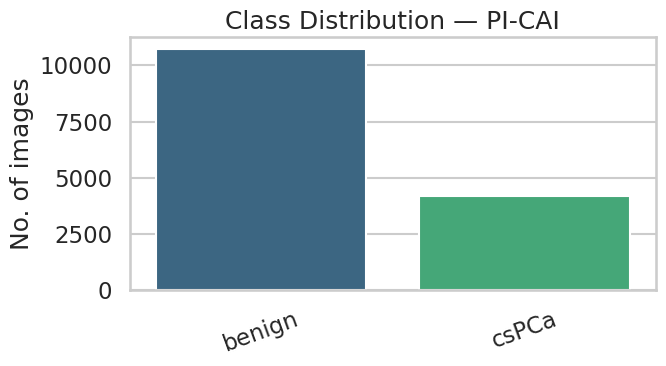

In [ ]:
# STEP 3 — BUILD THE MASTER DATAFRAME (image path + label + patient id)

def build_dataframe(root):
    rows = []
    for p in Path(root).rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXT:
            rows.append({"path": str(p), "class_folder": p.parent.name})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(" Kono image pai nai. CFG['DATA_ROOT'] check koro.")

    # train/test/val naam er folder class hishebe nite parbo na — sekhetre parent er parent
    split_words = {"train", "test", "val", "valid", "validation", "images", "data"}
    if df["class_folder"].str.lower().isin(split_words).all():
        df["class_folder"] = df["path"].apply(lambda x: Path(x).parent.parent.name)

    # patient id extract (data leakage prevent korte)
    pat = re.compile(CFG["PATIENT_REGEX"])
    def get_pid(fp):
        m = pat.search(Path(fp).stem)
        return m.group(1) if m else Path(fp).stem   # na paile filename tai id
    df["patient_id"] = df["path"].apply(get_pid)
    return df

df = build_dataframe(CFG["DATA_ROOT"])

print(f" Total images : {len(df)}")
print(f" Unique classes: {df['class_folder'].nunique()}")
print(df["class_folder"].value_counts())
print(f" Unique patients (approx): {df['patient_id'].nunique()}")

# --- label encode ---
CLASSES = sorted(df["class_folder"].unique().tolist())
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}
df["label"] = df["class_folder"].map(CLASS2IDX)
NUM_CLASSES = len(CLASSES)
print(f"\n Classes -> {CLASS2IDX}")

# --- class distribution plot (paper er Figure 1 hote pare) ---
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="class_folder", order=CLASSES, palette="viridis")
plt.title("Class Distribution — PI-CAI"); plt.xlabel(""); plt.ylabel("No. of images")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(f"{CFG['OUT_DIR']}/class_distribution.png", dpi=300); plt.show()


In [ ]:
# STEP 4 — TRAIN / VAL / TEST SPLIT  (patient-wise, stratified)
def make_splits(df):
    if CFG["GROUP_SPLIT"] and df["patient_id"].nunique() > 10:
        # patient-wise (group) split — recommended
        gss = GroupShuffleSplit(n_splits=1, test_size=CFG["TEST_SIZE"], random_state=CFG["SEED"])
        tr_idx, te_idx = next(gss.split(df, groups=df["patient_id"]))
        df_tr_full, df_te = df.iloc[tr_idx], df.iloc[te_idx]

        gss2 = GroupShuffleSplit(n_splits=1,
                                 test_size=CFG["VAL_SIZE"]/(1-CFG["TEST_SIZE"]),
                                 random_state=CFG["SEED"])
        tr_idx2, va_idx2 = next(gss2.split(df_tr_full, groups=df_tr_full["patient_id"]))
        df_tr, df_va = df_tr_full.iloc[tr_idx2], df_tr_full.iloc[va_idx2]
        mode = "patient-wise (GroupShuffleSplit)"
    else:
        # simple stratified split (patient id na thakle)
        df_tr_full, df_te = train_test_split(df, test_size=CFG["TEST_SIZE"],
                                             stratify=df["label"], random_state=CFG["SEED"])
        df_tr, df_va = train_test_split(df_tr_full,
                                        test_size=CFG["VAL_SIZE"]/(1-CFG["TEST_SIZE"]),
                                        stratify=df_tr_full["label"], random_state=CFG["SEED"])
        mode = "stratified (image-wise)"
    return df_tr.reset_index(drop=True), df_va.reset_index(drop=True), df_te.reset_index(drop=True), mode

df_train, df_val, df_test, split_mode = make_splits(df)
print(f" Split mode: {split_mode}")
print(f"   Train: {len(df_train):>6}  |  Val: {len(df_val):>6}  |  Test: {len(df_test):>6}")
for name, d in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"   {name} class dist: {dict(d['class_folder'].value_counts())}")


 Split mode: patient-wise (GroupShuffleSplit)
   Train:  10420  |  Val:   2247  |  Test:   2238
   Train class dist: {'benign': np.int64(7471), 'csPCa': np.int64(2949)}
   Val class dist: {'benign': np.int64(1596), 'csPCa': np.int64(651)}
   Test class dist: {'benign': np.int64(1644), 'csPCa': np.int64(594)}


 Batch shape: (32, 3, 224, 224)  labels: [1, 1, 1, 0, 1, 0, 0, 1]


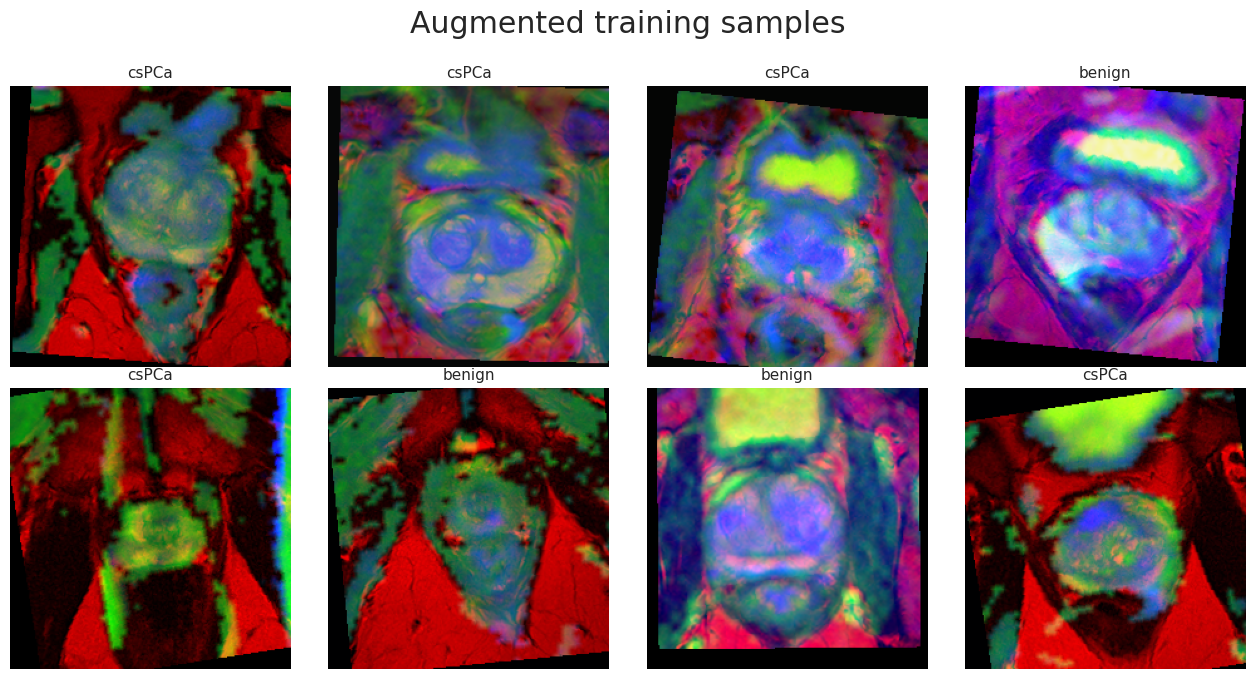

In [ ]:
# STEP 5 — DATASET, AUGMENTATION & DATALOADER
from torchvision import transforms as T

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize((CFG["IMG_SIZE"], CFG["IMG_SIZE"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.92, 1.08)),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.20, scale=(0.02, 0.08)),   # regularization
])

eval_tf = T.Compose([
    T.Resize((CFG["IMG_SIZE"], CFG["IMG_SIZE"])),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PICAIDataset(Dataset):
    """Simple image-path based dataset. Grayscale MRI -> 3-channel RGB (pretrained weights er jonno)."""
    def __init__(self, dataframe, transform):
        self.paths  = dataframe["path"].values
        self.labels = dataframe["label"].values
        self.tf     = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), int(self.labels[i])

def make_loader(dataframe, transform, shuffle=False, balance=False, bs=None):
    ds = PICAIDataset(dataframe, transform)
    bs = bs or CFG["BATCH_SIZE"]
    if balance:
        # minority class er sample beshi bar dekhabe (imbalance fix)
        counts = Counter(dataframe["label"].tolist())
        w = np.array([1.0 / counts[l] for l in dataframe["label"]], dtype=np.float32)
        sampler = WeightedRandomSampler(torch.from_numpy(w), num_samples=len(w), replacement=True)
        return DataLoader(ds, batch_size=bs, sampler=sampler,
                          num_workers=CFG["NUM_WORKERS"], pin_memory=True, drop_last=True)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=CFG["NUM_WORKERS"], pin_memory=True)

train_loader = make_loader(df_train, train_tf, shuffle=True, balance=CFG["BALANCE"])
val_loader   = make_loader(df_val,   eval_tf)
test_loader  = make_loader(df_test,  eval_tf)

# --- sanity check: ekta batch dekhe nao ---
xb, yb = next(iter(train_loader))
print(f" Batch shape: {tuple(xb.shape)}  labels: {yb[:8].tolist()}")

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, img, lb in zip(axes.ravel(), xb, yb):
    im = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
    ax.imshow(np.clip(im, 0, 1)); ax.set_title(CLASSES[lb], fontsize=11); ax.axis("off")
plt.suptitle("Augmented training samples"); plt.tight_layout()
plt.savefig(f"{CFG['OUT_DIR']}/sample_batch.png", dpi=200); plt.show()


In [ ]:
# STEP 6 — MODEL DEFINITIONS

class HybridCNNTransformer(nn.Module):
    """
    Proposed hybrid: ResNet-50 er stage-3 feature map (1024 x 14 x 14) ke
    196-ta token banano hoy -> learnable CLS token + positional embedding ->
    Transformer encoder (global context) -> CLS token diye classification.

    Kano kaj kore: CNN local texture (lesion edge, heterogeneity) dhore,
    Transformer distant region er moddhe relation dhore. MRI te lesion er
    context (zone, gland boundary) important — tai duita mile bhalo hoy.
    """
    def __init__(self, num_classes, embed_dim=384, depth=4, num_heads=6,
                 drop=0.1, backbone="resnet50", pretrained=True):
        super().__init__()
        # --- CNN feature extractor (stage 3 output) ---
        self.backbone = timm.create_model(backbone, pretrained=pretrained,
                                          features_only=True, out_indices=(3,))
        cnn_ch = self.backbone.feature_info.channels()[-1]     # resnet50 -> 1024

        # --- CNN channel -> transformer embedding dim ---
        self.proj = nn.Conv2d(cnn_ch, embed_dim, kernel_size=1)

        # --- CLS token + positional embedding ---
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + 14*14, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.pos_drop = nn.Dropout(drop)

        # --- Transformer encoder ---
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim*4,
            dropout=drop, activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

        # --- classification head ---
        self.head = nn.Sequential(nn.Dropout(drop), nn.Linear(embed_dim, num_classes))

    def forward(self, x):
        f = self.backbone(x)[-1]                 # B, C, H, W
        f = self.proj(f)                         # B, D, H, W
        B, D, H, W = f.shape
        t = f.flatten(2).transpose(1, 2)         # B, HW, D  (patch tokens)
        cls = self.cls_token.expand(B, -1, -1)   # B, 1, D
        t = torch.cat([cls, t], dim=1)           # B, 1+HW, D
        # image size CFG er sathe na milele pos_embed interpolate
        if t.shape[1] != self.pos_embed.shape[1]:
            pe_cls, pe_grid = self.pos_embed[:, :1], self.pos_embed[:, 1:]
            g = int(pe_grid.shape[1] ** 0.5)
            pe_grid = pe_grid.reshape(1, g, g, D).permute(0, 3, 1, 2)
            pe_grid = F.interpolate(pe_grid, size=(H, W), mode="bicubic", align_corners=False)
            pe_grid = pe_grid.permute(0, 2, 3, 1).reshape(1, H*W, D)
            pos = torch.cat([pe_cls, pe_grid], dim=1)
        else:
            pos = self.pos_embed
        t = self.pos_drop(t + pos)
        t = self.encoder(t)
        return self.head(self.norm(t[:, 0]))     # CLS token -> logits


def build_model(name, num_classes=NUM_CLASSES):
    """Model registry — ekhane notun model add korte parba easily."""
    if name == "Hybrid-CNN-Transformer":
        return HybridCNNTransformer(num_classes)
    if name == "MaxViT-T (hybrid)":
        # timm er ready-made CNN+Transformer hybrid (optional baseline)
        return timm.create_model("maxvit_tiny_tf_224.in1k", pretrained=True,
                                 num_classes=num_classes)
    return timm.create_model(TIMM_NAME[name], pretrained=True, num_classes=num_classes,
                             drop_rate=0.2)

# --- model zoo: display name -> timm name + model-specific learning rate ---
TIMM_NAME = {
    "ResNet-50":       "resnet50",
    "EfficientNet-B3": "efficientnet_b3",
    "ViT-B/16":        "vit_base_patch16_224",
    "Swin-T":          "swin_tiny_patch4_window7_224",
}

# Transformer gulo choto LR pochondo kore, CNN ektu boro LR. Ei tuning ta
# important — same LR dile ViT/Swin under-perform korbe ar comparison unfair hobe.
MODEL_ZOO = {
    "ResNet-50":              {"lr": 3e-4, "family": "CNN"},
    "EfficientNet-B3":        {"lr": 3e-4, "family": "CNN"},
    "ViT-B/16":               {"lr": 5e-5, "family": "Transformer"},
    "Swin-T":                 {"lr": 1e-4, "family": "Transformer"},
    "Hybrid-CNN-Transformer": {"lr": 2e-4, "family": "Hybrid (proposed)"},
    # "MaxViT-T (hybrid)":    {"lr": 1e-4, "family": "Hybrid"},   # chaile un-comment
}

# --- quick shape test (train shuru korar age bug dhorar jonno) ---
_m = build_model("Hybrid-CNN-Transformer")
with torch.no_grad():
    out = _m(torch.randn(2, 3, CFG["IMG_SIZE"], CFG["IMG_SIZE"]))
print(f" Hybrid output shape: {tuple(out.shape)} (expected: (2, {NUM_CLASSES}))")
print(f"   Params: {sum(p.numel() for p in _m.parameters())/1e6:.2f} M")
del _m


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

 Hybrid output shape: (2, 2) (expected: (2, 2))
   Params: 16.11 M


In [ ]:
# STEP 7 — TRAIN & EVALUATE FUNCTIONS
def class_weights(dataframe):
    """Imbalanced hole loss e weight — WeightedSampler er sathe complement kore."""
    counts = np.array([ (dataframe["label"] == i).sum() for i in range(NUM_CLASSES) ], dtype=np.float32)
    w = counts.sum() / (NUM_CLASSES * np.maximum(counts, 1))
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Return loss, true labels, predicted labels, predicted probabilities."""
    model.eval()
    losses, ys, ps, probs = [], [], [], []
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=CFG["USE_AMP"]):
            logit = model(x)
            if criterion is not None:
                losses.append(criterion(logit, y).item())
        p = torch.softmax(logit.float(), dim=1)
        probs.append(p.cpu().numpy()); ys.append(y.cpu().numpy())
        ps.append(p.argmax(1).cpu().numpy())
    return (float(np.mean(losses)) if losses else 0.0,
            np.concatenate(ys), np.concatenate(ps), np.concatenate(probs))

def safe_auc(y_true, y_prob):
    """Binary -> normal AUC, multiclass -> macro one-vs-rest AUC."""
    try:
        if NUM_CLASSES == 2:
            return roc_auc_score(y_true, y_prob[:, 1])
        return roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        return float("nan")

def train_one_model(name, cfg_model):
    """Ekta model full train kore best checkpoint + test prediction return kore."""
    print("\n" + "="*78)
    print(f" TRAINING: {name}  ({cfg_model['family']})")
    print("="*78)
    seed_everything(CFG["SEED"])                     # protita model same seed theke shuru

    model = build_model(name).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6

    criterion = nn.CrossEntropyLoss(weight=class_weights(df_train),
                                    label_smoothing=CFG["LABEL_SMOOTH"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg_model["lr"],
                                  weight_decay=CFG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=cfg_model["lr"], epochs=CFG["EPOCHS"],
        steps_per_epoch=max(1, len(train_loader)), pct_start=0.25)
    scaler = torch.amp.GradScaler(enabled=(CFG["USE_AMP"] and DEVICE.type == "cuda"))

    best_auc, best_state, patience, history = -1.0, None, 0, []
    t0 = time.time()

    for epoch in range(1, CFG["EPOCHS"] + 1):
        # ---------------- train ----------------
        model.train(); run_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"  Epoch {epoch:02d}/{CFG['EPOCHS']}", leave=False)
        for x, y in pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=CFG["USE_AMP"]):
                logit = model(x); loss = criterion(logit, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # transformer stability
            scaler.step(optimizer); scaler.update(); scheduler.step()

            run_loss += loss.item() * y.size(0)
            correct  += (logit.argmax(1) == y).sum().item(); total += y.size(0)
            pbar.set_postfix(loss=f"{run_loss/total:.4f}", acc=f"{correct/total:.3f}")

        tr_loss, tr_acc = run_loss/total, correct/total

        # ---------------- validate ----------------
        va_loss, yv, pv, probv = evaluate(model, val_loader, criterion)
        va_acc = accuracy_score(yv, pv)
        va_f1  = precision_recall_fscore_support(yv, pv, average="macro", zero_division=0)[2]
        va_auc = safe_auc(yv, probv)
        history.append(dict(epoch=epoch, train_loss=tr_loss, train_acc=tr_acc,
                            val_loss=va_loss, val_acc=va_acc, val_f1=va_f1, val_auc=va_auc))
        print(f"  Epoch {epoch:02d} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
              f"|| val_loss {va_loss:.4f} acc {va_acc:.4f} F1 {va_f1:.4f} AUC {va_auc:.4f}")

        # ---------------- early stopping (val AUC er upor) ----------------
        score = va_auc if not np.isnan(va_auc) else va_f1
        if score > best_auc:
            best_auc, patience = score, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, f"{CFG['OUT_DIR']}/best_{name.replace('/','-')}.pt")
            print(f"     best model saved (score {score:.4f})")
        else:
            patience += 1
            if patience >= CFG["EARLY_STOP"]:
                print(f"    Early stop at epoch {epoch}")
                break

    train_time = time.time() - t0

    # ---------------- final test evaluation (best checkpoint diye) ----------------
    model.load_state_dict(best_state)
    _, yt, pt, probt = evaluate(model, test_loader)

    # inference speed (ms per image) — deployment er jonno important metric
    model.eval(); dummy = torch.randn(1, 3, CFG["IMG_SIZE"], CFG["IMG_SIZE"]).to(DEVICE)
    with torch.no_grad():
        for _ in range(10): model(dummy)                       # warm-up
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        ts = time.time()
        for _ in range(50): model(dummy)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        infer_ms = (time.time() - ts) / 50 * 1000

    del model; torch.cuda.empty_cache()
    return dict(name=name, family=cfg_model["family"], params_M=n_params,
                train_time_s=train_time, infer_ms=infer_ms,
                history=history, y_true=yt, y_pred=pt, y_prob=probt)


In [ ]:
# STEP 8 — METRIC CALCULATOR
def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    prw, rcw, f1w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    # specificity = TN / (TN + FP), per class ta average kora holo
    specs = []
    for i in range(NUM_CLASSES):
        tp = cm[i, i]; fn = cm[i].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
        specs.append(tn / (tn + fp) if (tn + fp) else 0.0)

    return {
        "Accuracy":    acc,
        "Precision":   pr,
        "Recall/Sens": rc,
        "Specificity": float(np.mean(specs)),
        "F1":          f1,
        "F1 (wtd)":    f1w,
        "AUC":         safe_auc(y_true, y_prob),
        "MCC":         matthews_corrcoef(y_true, y_pred),
        "Kappa":       cohen_kappa_score(y_true, y_pred),
    }


In [ ]:
# STEP 9 — MAIN LOOP: SOB MODEL EK EK KORE TRAIN + EVALUATE
RESULTS, RAW = [], {}

for mname, mcfg in MODEL_ZOO.items():
    try:
        r = train_one_model(mname, mcfg)
        m = compute_metrics(r["y_true"], r["y_pred"], r["y_prob"])
        RESULTS.append({
            "Model": mname, "Family": r["family"],
            **{k: round(v, 4) for k, v in m.items()},
            "Params (M)": round(r["params_M"], 2),
            "Train time (s)": round(r["train_time_s"], 1),
            "Inference (ms)": round(r["infer_ms"], 2),
        })
        RAW[mname] = r
        print(f"\n {mname} TEST RESULTS:")
        for k, v in m.items(): print(f"     {k:<12}: {v:.4f}")
        # intermediate save — kono model crash korleo age er result thakbe
        pd.DataFrame(RESULTS).to_csv(f"{CFG['OUT_DIR']}/comparison_partial.csv", index=False)
    except RuntimeError as e:
        print(f" {mname} failed: {e}")
        print("    Tip: CUDA OOM hole CFG['BATCH_SIZE'] komiye 16 ba 8 koro.")
        torch.cuda.empty_cache()

results_df = pd.DataFrame(RESULTS).sort_values("AUC", ascending=False).reset_index(drop=True)
results_df.to_csv(f"{CFG['OUT_DIR']}/model_comparison.csv", index=False)
print("\n Sob model train complete.")



 TRAINING: ResNet-50  (CNN)


  Epoch 01/20:   0%|          | 0/325 [00:00<?, ?it/s]

  Epoch 01 | train_loss 0.6281 acc 0.5066 || val_loss 0.9316 acc 0.2897 F1 0.2246 AUC 0.5045
     best model saved (score 0.5045)


  Epoch 02/20:   0%|          | 0/325 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a74f0e3f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a74f0e3f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

...

  Epoch 12/20:   0%|          | 0/325 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a74f0e3f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a74f0e3f420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

  Epoch 12 | train_loss 0.2252 acc 0.9281 || val_loss 0.9448 acc 0.6636 F1 0.6227 AUC 0.6880


  Epoch 13/20:   0%|          | 0/325 [00:00<?, ?it/s]

  Epoch 13 | train_loss 0.2091 acc 0.9359 || val_loss 1.0451 acc 0.6453 F1 0.6148 AUC 0.6899
    Early stop at epoch 13

 Hybrid-CNN-Transformer TEST RESULTS:
     Accuracy    : 0.6309
     Precision   : 0.6000
     Recall/Sens : 0.6257
     Specificity : 0.6257
     F1          : 0.5931
     F1 (wtd)    : 0.6513
     AUC         : 0.6832
     MCC         : 0.2242
     Kappa       : 0.2098

 Sob model train complete.


In [ ]:
# STEP 10 — COMPARISON TABLE (paper er Table 2 hisebe use)

pd.set_option("display.width", 200, "display.max_columns", 50)
print("\n" + "="*100)
print(" FINAL MODEL COMPARISON — PI-CAI Prostate Cancer Classification")
print("="*100)
print(results_df.to_string(index=False))

best = results_df.iloc[0]
print("\n" + "="*100)
print(f" BEST MODEL: {best['Model']}  ({best['Family']})")
print(f"   AUC {best['AUC']:.4f} | Accuracy {best['Accuracy']:.4f} | F1 {best['F1']:.4f} "
      f"| Sensitivity {best['Recall/Sens']:.4f} | Specificity {best['Specificity']:.4f}")
print("="*100)

# LaTeX table — direct Overleaf e paste
latex = results_df[["Model", "Accuracy", "Precision", "Recall/Sens",
                    "Specificity", "F1", "AUC", "Params (M)"]].to_latex(
    index=False, float_format="%.4f",
    caption="Performance comparison of CNN, Transformer and hybrid architectures on the PI-CAI dataset.",
    label="tab:model_comparison")
with open(f"{CFG['OUT_DIR']}/comparison_table.tex", "w") as f:
    f.write(latex)
print("\n LaTeX table saved -> comparison_table.tex")



 FINAL MODEL COMPARISON — PI-CAI Prostate Cancer Classification
                 Model            Family  Accuracy  Precision  Recall/Sens  Specificity     F1  F1 (wtd)    AUC    MCC  Kappa  Params (M)  Train time (s)  Inference (ms)
                Swin-T       Transformer    0.6157     0.6325       0.6691       0.6691 0.5997    0.6373 0.7171 0.2994 0.2555       27.52           862.2           16.75
             ResNet-50               CNN    0.4352     0.6228       0.5994       0.5994 0.4325    0.4142 0.7097 0.2210 0.1207       23.51           673.6            6.10
       EfficientNet-B3               CNN    0.6081     0.6119       0.6435       0.6435 0.5869    0.6308 0.6851 0.2535 0.2221       10.70           974.4           13.96
Hybrid-CNN-Transformer Hybrid (proposed)    0.6309     0.6000       0.6257       0.6257 0.5931    0.6513 0.6832 0.2242 0.2098       16.11          1014.2            7.50
              ViT-B/16       Transformer    0.6671     0.6201       0.6460       0.64

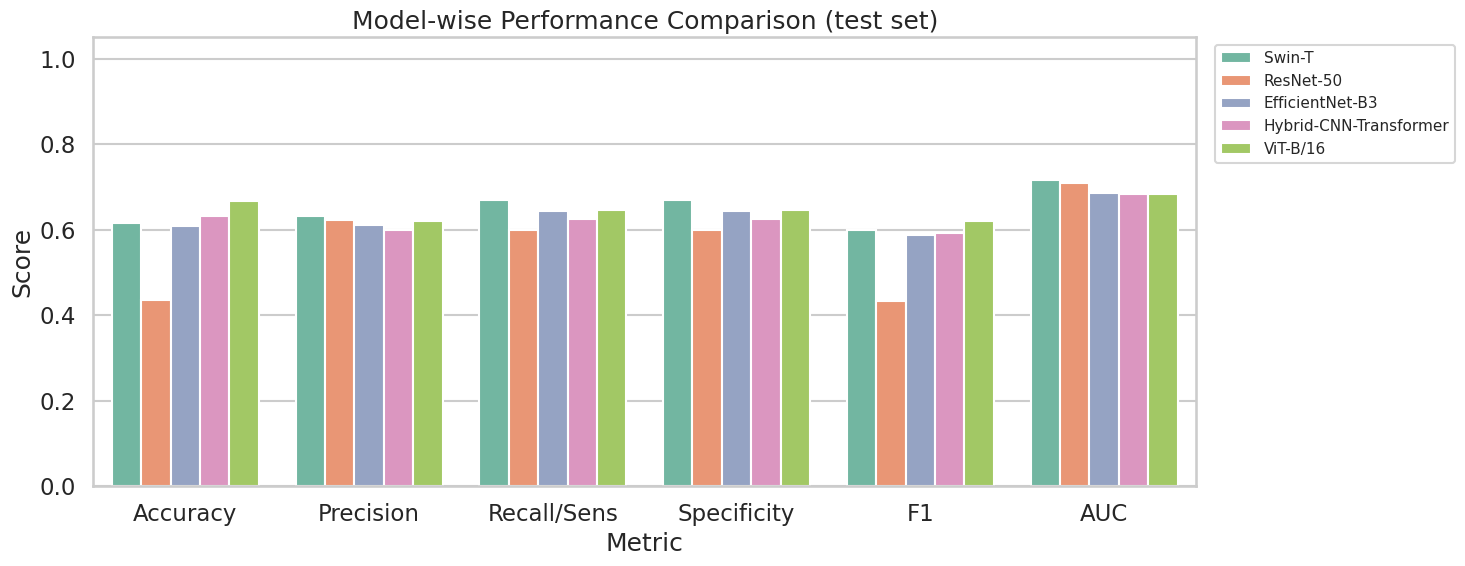

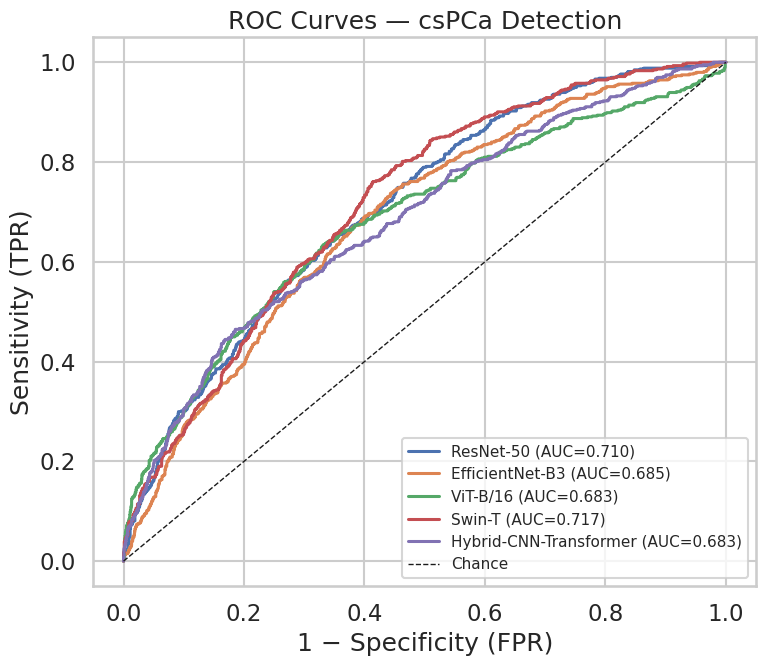

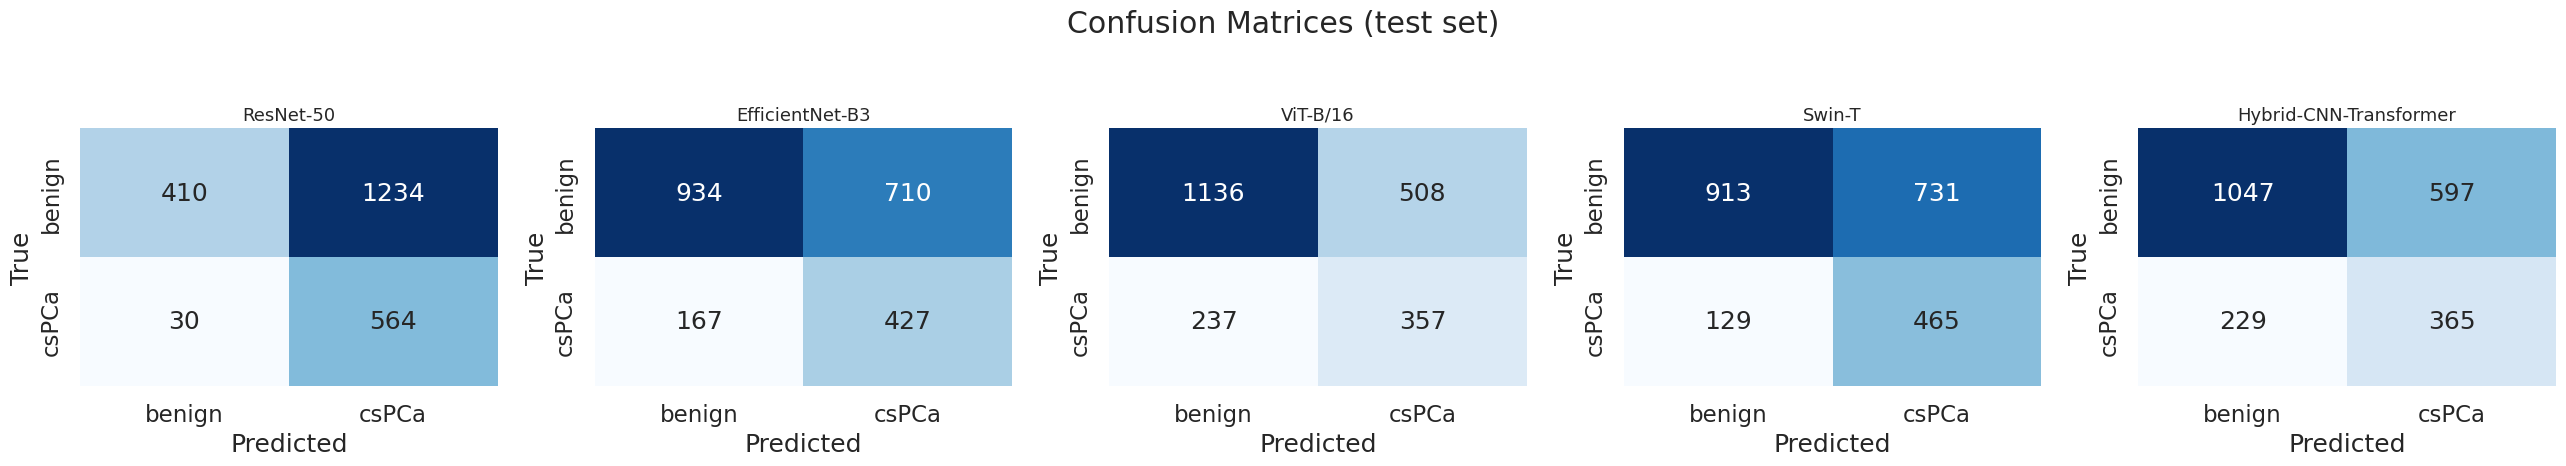

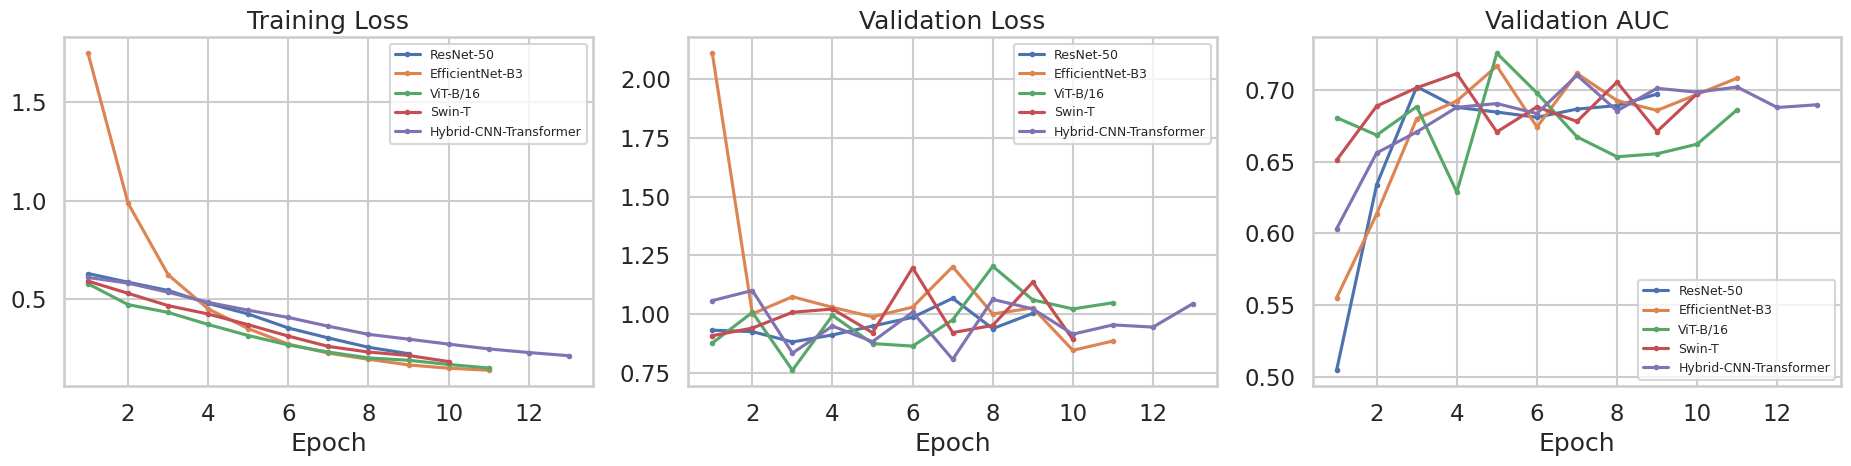

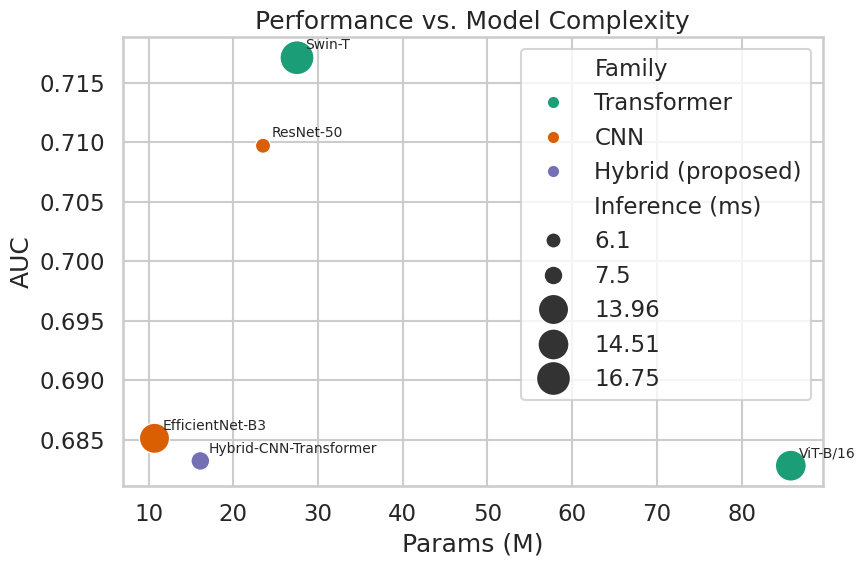

In [ ]:
# STEP 11 — VISUAL COMPARISON (bar chart, ROC, confusion matrix, curves)

# ---------- 11.1 grouped bar chart: metric-wise comparison ----------
metrics_to_plot = ["Accuracy", "Precision", "Recall/Sens", "Specificity", "F1", "AUC"]
plot_df = results_df.melt(id_vars="Model", value_vars=metrics_to_plot,
                          var_name="Metric", value_name="Score")
plt.figure(figsize=(15, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2")
plt.ylim(0, 1.05); plt.title("Model-wise Performance Comparison (test set)")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=11)
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/fig_metric_comparison.png", dpi=300); plt.show()

# ---------- 11.2 ROC curves (binary hole) ----------
if NUM_CLASSES == 2:
    plt.figure(figsize=(8, 7))
    for mname, r in RAW.items():
        fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"][:, 1])
        auc_v = safe_auc(r["y_true"], r["y_prob"])
        plt.plot(fpr, tpr, lw=2.2, label=f"{mname} (AUC={auc_v:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    plt.xlabel("1 − Specificity (FPR)"); plt.ylabel("Sensitivity (TPR)")
    plt.title("ROC Curves — csPCa Detection"); plt.legend(loc="lower right", fontsize=11)
    plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/fig_roc_curves.png", dpi=300); plt.show()

# ---------- 11.3 confusion matrices (sob model pashapashi) ----------
n = len(RAW)
fig, axes = plt.subplots(1, n, figsize=(5.2*n, 4.6))
axes = np.atleast_1d(axes)
for ax, (mname, r) in zip(axes, RAW.items()):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(mname, fontsize=13); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Confusion Matrices (test set)", y=1.03)
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/fig_confusion_matrices.png",
                                dpi=300, bbox_inches="tight"); plt.show()

# ---------- 11.4 training curves (convergence behaviour) ----------
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for mname, r in RAW.items():
    h = pd.DataFrame(r["history"])
    axes[0].plot(h["epoch"], h["train_loss"], marker="o", ms=3, label=mname)
    axes[1].plot(h["epoch"], h["val_loss"],   marker="o", ms=3, label=mname)
    axes[2].plot(h["epoch"], h["val_auc"],    marker="o", ms=3, label=mname)
for ax, t in zip(axes, ["Training Loss", "Validation Loss", "Validation AUC"]):
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{CFG['OUT_DIR']}/fig_training_curves.png", dpi=300); plt.show()

# ---------- 11.5 accuracy vs model size (efficiency trade-off) ----------
plt.figure(figsize=(9, 6))
sns.scatterplot(data=results_df, x="Params (M)", y="AUC", hue="Family",
                size="Inference (ms)", sizes=(120, 600), palette="Dark2")
for _, row in results_df.iterrows():
    plt.annotate(row["Model"], (row["Params (M)"], row["AUC"]),
                 xytext=(6, 6), textcoords="offset points", fontsize=10)
plt.title("Performance vs. Model Complexity"); plt.tight_layout()
plt.savefig(f"{CFG['OUT_DIR']}/fig_efficiency_tradeoff.png", dpi=300); plt.show()



 PATIENT-LEVEL (case-level) COMPARISON — eta paper er main table
                 Model Aggregation  Patients    AUC  Accuracy  Sensitivity  Specificity     F1
Hybrid-CNN-Transformer         max       213 0.7968    0.3944       1.0000       0.1783 0.4647
                Swin-T         max       213 0.7755    0.4085       1.0000       0.1975 0.4706
                Swin-T        mean       213 0.7623    0.6338       0.8393       0.5605 0.5465
             ResNet-50         max       213 0.7592    0.2958       1.0000       0.0446 0.4275
             ResNet-50        mean       213 0.7572    0.4131       0.9821       0.2102 0.4681
              ViT-B/16        mean       213 0.7440    0.7136       0.6607       0.7325 0.5481
       EfficientNet-B3        mean       213 0.7332    0.6291       0.7321       0.5924 0.5093
Hybrid-CNN-Transformer        mean       213 0.7292    0.6667       0.6607       0.6688 0.5103
              ViT-B/16         max       213 0.7263    0.4272       0.9107     

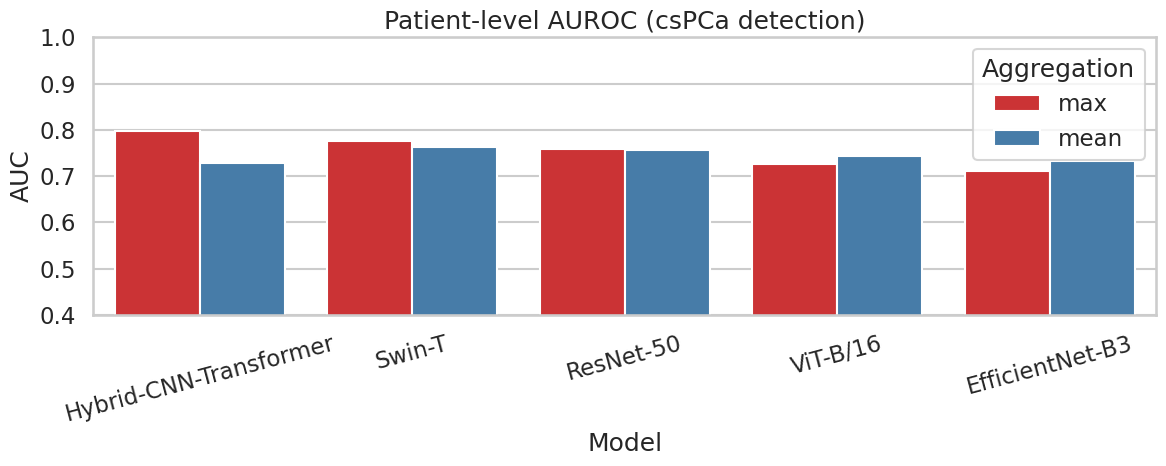

In [ ]:
# STEP 11.6 — PATIENT-LEVEL (CASE-LEVEL) EVALUATION  ***PAPER ER JONNO MUST***
# Amader label ta CASE-level (ek patient csPCa positive kina), kintu train
# hoyeche SLICE-level e. Tar mane ekta positive case er onek slice e asole
# lesion nai — eta weak/noisy label (MIL problem).
#
# Tai clinical metric ta patient-level e report korte hobe: ek patient er sob
# slice er probability aggregate (mean ba max) kore ekta case-level score.
# PI-CAI challenge nijeo patient-level AUROC diye evaluate kore.
# Reviewer ei number ta-i dekhbe — slice-level ta supplementary.

if NUM_CLASSES == 2:
    pat_rows = []
    for mname, r in RAW.items():
        d = pd.DataFrame({
            "pid":  df_test["patient_id"].values,   # test_loader shuffle=False -> order same
            "y":    r["y_true"],
            "prob": r["y_prob"][:, 1],
        })
        g = d.groupby("pid").agg(y=("y", "max"),
                                 p_mean=("prob", "mean"),
                                 p_max=("prob", "max")).reset_index()
        for agg in ["p_mean", "p_max"]:
            auc  = roc_auc_score(g["y"], g[agg])
            pred = (g[agg] >= 0.5).astype(int)
            pr, rc, f1, _ = precision_recall_fscore_support(g["y"], pred,
                                                            average="binary", zero_division=0)
            tn, fp, fn, tp = confusion_matrix(g["y"], pred, labels=[0, 1]).ravel()
            pat_rows.append({
                "Model": mname, "Aggregation": "mean" if agg == "p_mean" else "max",
                "Patients": len(g), "AUC": round(auc, 4),
                "Accuracy": round(accuracy_score(g["y"], pred), 4),
                "Sensitivity": round(rc, 4),
                "Specificity": round(tn / (tn + fp) if (tn + fp) else 0, 4),
                "F1": round(f1, 4),
            })
    patient_df = pd.DataFrame(pat_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
    patient_df.to_csv(f"{CFG['OUT_DIR']}/patient_level_comparison.csv", index=False)
    print("\n PATIENT-LEVEL (case-level) COMPARISON — eta paper er main table")
    print(patient_df.to_string(index=False))

    plt.figure(figsize=(12, 5))
    sns.barplot(data=patient_df, x="Model", y="AUC", hue="Aggregation", palette="Set1")
    plt.ylim(0.4, 1.0); plt.title("Patient-level AUROC (csPCa detection)")
    plt.xticks(rotation=15); plt.tight_layout()
    plt.savefig(f"{CFG['OUT_DIR']}/fig_patient_level_auc.png", dpi=300); plt.show()
else:
    print("  Patient-level aggregation ekhon sudhu binary task er jonno lekha.")


In [ ]:
# STEP 12 — STATISTICAL SIGNIFICANCE (McNemar test)
# Best model ar baki sob model er difference ta ki really significant, naki
# random? Reviewer ei question ta obossoi korbe.
from statsmodels.stats.contingency_tables import mcnemar

best_name = results_df.iloc[0]["Model"]
best_r = RAW[best_name]
rows = []
for mname, r in RAW.items():
    if mname == best_name:
        continue
    a = (best_r["y_pred"] == best_r["y_true"])   # best model correct?
    b = (r["y_pred"] == r["y_true"])             # onno model correct?
    table = [[np.sum(a & b),  np.sum(a & ~b)],
             [np.sum(~a & b), np.sum(~a & ~b)]]
    res = mcnemar(table, exact=False, correction=True)
    rows.append({"Comparison": f"{best_name} vs {mname}",
                 "chi2": round(float(res.statistic), 4),
                 "p-value": float(res.pvalue),
                 "Significant (p<0.05)": "Yes" if res.pvalue < 0.05 else "No"})

stat_df = pd.DataFrame(rows)
stat_df.to_csv(f"{CFG['OUT_DIR']}/mcnemar_tests.csv", index=False)
print("\n McNemar Test — best model vs others")
print(stat_df.to_string(index=False))



 McNemar Test — best model vs others
                      Comparison     chi2      p-value Significant (p<0.05)
             Swin-T vs ResNet-50 225.5681 5.519705e-51                  Yes
       Swin-T vs EfficientNet-B3   0.4083 5.228370e-01                   No
              Swin-T vs ViT-B/16  19.3105 1.110908e-05                  Yes
Swin-T vs Hybrid-CNN-Transformer   1.5381 2.148955e-01                   No


In [ ]:
# STEP 13 — PER-CLASS REPORT + SAVE EVERYTHING
report_lines = []
for mname, r in RAW.items():
    rep = classification_report(r["y_true"], r["y_pred"], target_names=CLASSES,
                                digits=4, zero_division=0)
    report_lines.append(f"\n{'='*70}\n{mname}\n{'='*70}\n{rep}")
    print(report_lines[-1])

with open(f"{CFG['OUT_DIR']}/per_class_reports.txt", "w") as f:
    f.write("\n".join(report_lines))

# --- experiment metadata (reproducibility er jonno paper e dite hobe) ---
meta = {
    "dataset": "PI-CAI (Kaggle: varshithpsingh/prostate-cancer-pi-cai-dataset)",
    "n_images": int(len(df)), "classes": CLASSES,
    "split": {"mode": split_mode, "train": len(df_train),
              "val": len(df_val), "test": len(df_test)},
    "config": {k: v for k, v in CFG.items() if k != "DATA_ROOT"},
    "device": str(DEVICE),
    "results": RESULTS,
}
with open(f"{CFG['OUT_DIR']}/experiment_metadata.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)

# --- sob result zip kore download ---
import shutil
zip_base = "/kaggle/working/picai_results" if os.path.isdir("/kaggle/working") else "picai_results"
shutil.make_archive(zip_base, "zip", CFG["OUT_DIR"])
print(f"\n ZIP: {zip_base}.zip")
try:
    from google.colab import files          # Colab hole auto-download
    files.download(f"{zip_base}.zip")
except Exception:
    # Kaggle hole: right panel > Output > Download
    print(f" Kaggle e cholle: right panel -> Output -> {os.path.basename(zip_base)}.zip download koro")
print(f" Sob output: {os.path.abspath(CFG['OUT_DIR'])}")

print("\n DONE — comparison table, figures, checkpoints, LaTeX table sob save hoyeche.")



ResNet-50
              precision    recall  f1-score   support

      benign     0.9318    0.2494    0.3935      1644
       csPCa     0.3137    0.9495    0.4716       594

    accuracy                         0.4352      2238
   macro avg     0.6228    0.5994    0.4325      2238
weighted avg     0.7678    0.4352    0.4142      2238


EfficientNet-B3
              precision    recall  f1-score   support

      benign     0.8483    0.5681    0.6805      1644
       csPCa     0.3755    0.7189    0.4934       594

    accuracy                         0.6081      2238
   macro avg     0.6119    0.6435    0.5869      2238
weighted avg     0.7228    0.6081    0.6308      2238


ViT-B/16
              precision    recall  f1-score   support

      benign     0.8274    0.6910    0.7531      1644
       csPCa     0.4127    0.6010    0.4894       594

    accuracy                         0.6671      2238
   macro avg     0.6201    0.6460    0.6212      2238
weighted avg     0.7173    0.6671   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Sob output: /kaggle/working/picai_results

 DONE — comparison table, figures, checkpoints, LaTeX table sob save hoyeche.


***Happy Coding-Sayem***